In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/idhru/OneDrive/Desktop/zepto project/sql data/Zepto Grocery Data.csv")

In [6]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Total Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [8]:
df.shape


(8523, 12)

In [10]:
df.columns


Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Total Sales', 'Rating'],
      dtype='object')

In [11]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Total Sales                  float64
Rating                       float64
dtype: object

## **DATA CLEANING**

In [13]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [14]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat',
                                                         'low fat': 'Low Fat',
                                                         'reg': 'Regular',
                                                        })

In [15]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


# **BUISNESS REQUIREMENT**

### **KPI'S**

In [60]:
#Total Sales
total_sales = df['Total Sales'].sum()

#Average Sales
avg_sales = df['Total Sales'].mean()

#No Of Items Sold
no_of_items_sold = df['Total Sales'].count()

#Average Rating
avg_ratings = df['Rating'].mean()


print(f"TOTAL SALES: ${total_sales:,.0f}")
print(f"AVG SALES: ${avg_sales:,.0f}")
print(f"NO OF ITEMS SOLD: {no_of_items_sold:,.0f}")
print(f"AVG RATINGS: {avg_ratings:,.1f}")

TOTAL SALES: $1,201,681
AVG SALES: $141
NO OF ITEMS SOLD: 8,523
AVG RATINGS: 4.0


### **CHARTS REQUIREMENT**

###### **TOTAL SALES BY FAT CONTENT**

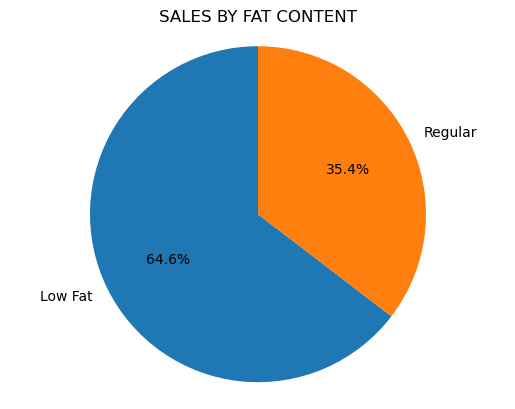

In [27]:
sales_by_fat = df.groupby('Item Fat Content')['Total Sales'].sum()

plt.pie(sales_by_fat, labels= sales_by_fat.index,
        autopct = '%.1f%%',
        startangle =90)

plt.title('SALES BY FAT CONTENT')
plt.axis('equal')
plt.show()

###### **TOTAL SALES BY ITEM TYPE**

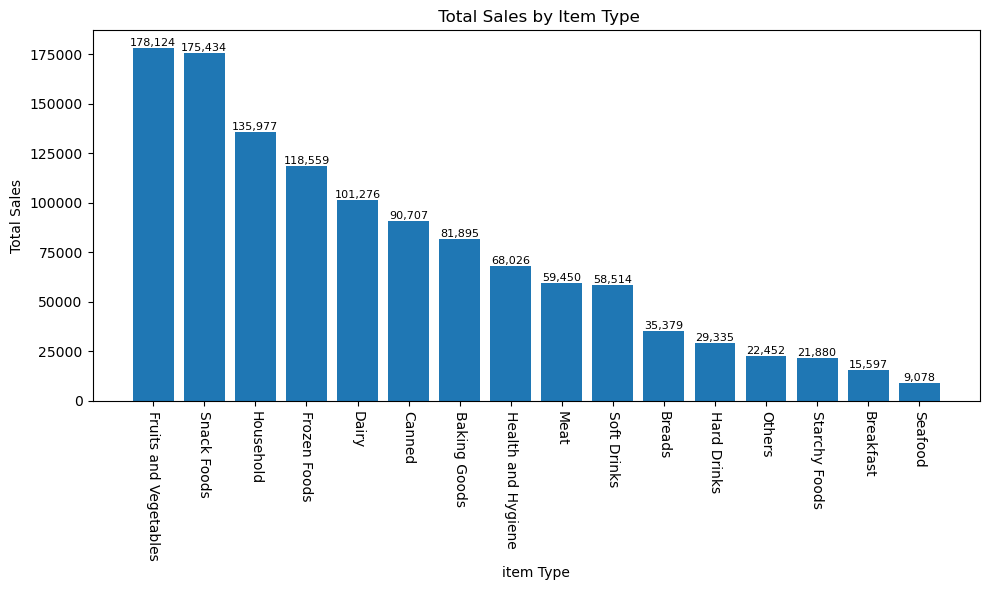

In [40]:
sales_by_type = df.groupby('Item Type')['Total Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks (rotation=-90)
plt.xlabel ('item Type')
plt.ylabel ('Total Sales')
plt.title(' Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}' , ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

###### **FAT CONTENT BY OUTLET FOR TOTAL SALES**

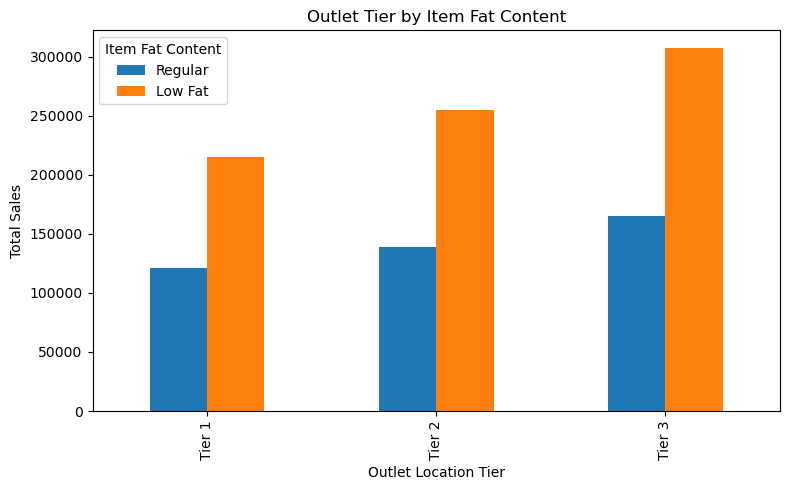

In [47]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Total Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title= 'Item Fat Content')
plt.tight_layout()
plt.show()

###### **TOTAL SALES BY OUTLET ESTABLISHMENT**

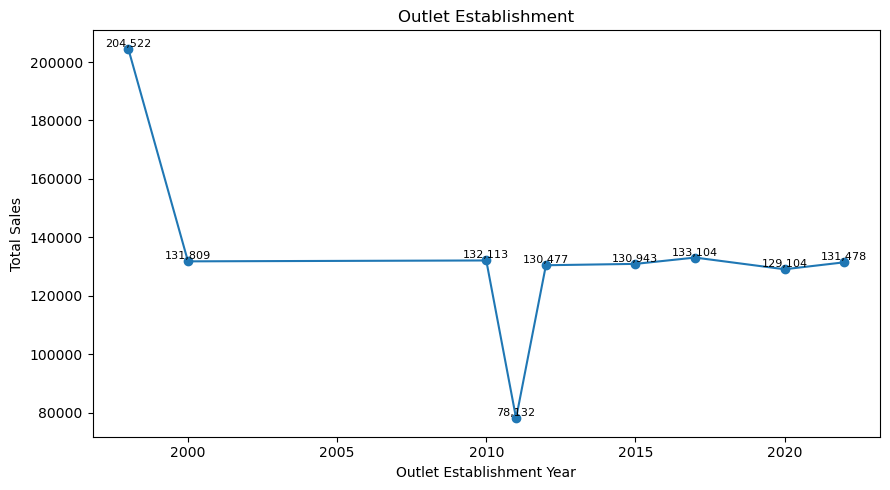

In [52]:
sales_by_year = df.groupby('Outlet Establishment Year')['Total Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x, y in zip(sales_by_year.index, sales_by_year.values): 
   plt.text (x,y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)
    
plt.tight_layout()
plt.show()

###### **SALES BY OUTLET SIZE**

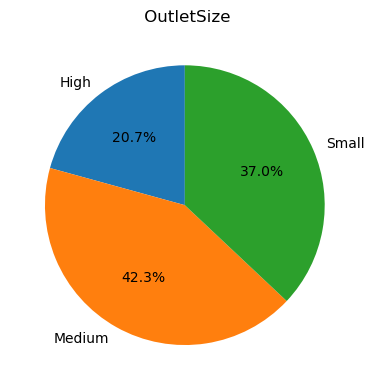

In [54]:
sales_by_size = df.groupby ('Outlet Size')['Total Sales'].sum()

plt.figure(figsize=(4, 4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title(' OutletSize')
plt.tight_layout()
plt.show()

###### **SALES BY OUTLET LOCATION**

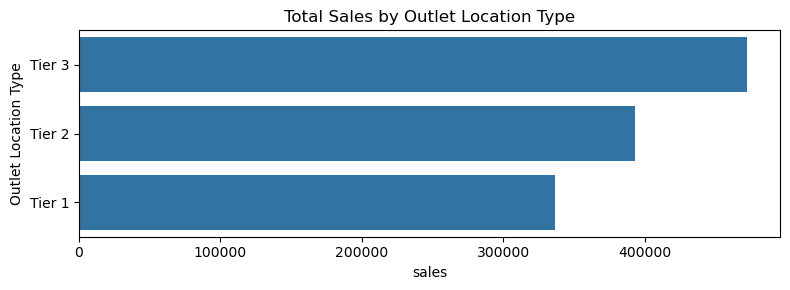

In [59]:
sales_by_location = df.groupby('Outlet Location Type') ['Total Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Total Sales', ascending=False)

plt.figure(figsize=(8, 3))
ax = sns. barplot (x='Total Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout() 
plt.show()